## Imports

In [35]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from src.random_forest import RandomForestClassifier
import pandas as pd


## Import and Load Dataset

In [26]:
dataset = load_breast_cancer()
X=dataset.data
y=dataset.target

print("Dataset Information:")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Feature names: {dataset.feature_names}")
print(f"\nClass distribution:")
print(f"Class 0 (malignant): {np.sum(y == 0)}")
print(f"Class 1 (benign): {np.sum(y == 1)}")

Dataset Information:
Number of samples: 569
Number of features: 30
Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Class distribution:
Class 0 (malignant): 212
Class 1 (benign): 357


### Data Preparation


### Splitting the dataset

In [27]:
X_train,X_temp,y_train,y_temp=train_test_split(X,y,test_size=0.30,stratify=y,random_state=42)
X_val,X_test,y_val,y_test=train_test_split(X_temp,y_temp,test_size=0.50,stratify=y_temp,random_state=42)

print(X_train.shape)
print(y_train.shape)

(398, 30)
(398,)


## Building the Random Forest Classifer

### Hyperparameter tuning

In [28]:
# Best parameters from Part C
max_depth=4
min_samples_split=2
n_features=X.shape[1]

n_estimators_values=[5,10,30,50]
max_features_values=[np.floor(np.sqrt(n_features)),np.floor(n_features/2)]

# Store the results
results=[]

best_val_acc=0
best_params=None
best_model=None

In [29]:
for n_estimators in n_estimators_values:
    for max_features in max_features_values:
        # Train Model
        model=RandomForestClassifier(max_depth,min_samples_split,n_estimators,max_features,bootstrap=True)
        model.fit(X_train,y_train)
        
        #Evaluate
        train_pred=model.predict(X_train)
        val_pred=model.predict(X_val)
        
        train_acc = accuracy_score(y_train, train_pred)
        val_acc = accuracy_score(y_val, val_pred)
        
        results.append({
            'n_estimators':n_estimators,
            'max_features':max_features,
            'train_accuracy':train_acc,
            'validation_accuracy':val_acc
        })
        
        print(f"Trees: {n_estimators:<3} Features: {int(max_features):<2} Train: {train_acc:.4f} Val: {val_acc:.4f}")
        
        # Track best model
        if val_acc>best_val_acc:
            best_val_acc=val_acc
            best_params=(n_estimators,max_features)
            best_model=model
print(f"\nBest params: n_estimators={best_params[0]}, max_features={best_params[1]}")
print(f"Best validation accuracy: {best_val_acc:.4f}")

Trees: 5   Features: 5  Train: 0.9774 Val: 0.9882
Trees: 5   Features: 15 Train: 0.9925 Val: 0.9765
Trees: 10  Features: 5  Train: 0.9849 Val: 0.9647
Trees: 10  Features: 15 Train: 0.9950 Val: 0.9647
Trees: 30  Features: 5  Train: 0.9950 Val: 0.9765
Trees: 30  Features: 15 Train: 0.9925 Val: 0.9882
Trees: 50  Features: 5  Train: 0.9925 Val: 0.9882
Trees: 50  Features: 15 Train: 0.9925 Val: 0.9882

Best params: n_estimators=5, max_features=5.0
Best validation accuracy: 0.9882


### Retrain on Train + validation with best hyperparameter

In [30]:
X_train_full=np.vstack([X_train,X_val])
y_train_full=np.hstack([y_train,y_val])
final_model = RandomForestClassifier(
    max_depth=max_depth, 
    min_samples_split=min_samples_split,
    n_estimators=best_params[0],  # Need to save this from grid search
    max_features=best_params[1],  # Need to save this from grid search
    bootstrap=True
)
final_model.fit(X_train_full,y_train_full)


### Evaluation

In [31]:
y_test_pred=final_model.predict(X_test)
test_acc=accuracy_score(y_test,y_test_pred)

print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.9070


### Performance Metrics

In [32]:
precision_class0 = precision_score(y_test, y_test_pred, pos_label=0)
precision_class1 = precision_score(y_test, y_test_pred, pos_label=1)
recall_class0 = recall_score(y_test, y_test_pred, pos_label=0)
recall_class1 = recall_score(y_test, y_test_pred, pos_label=1)
f1_class0 = f1_score(y_test, y_test_pred, pos_label=0)
f1_class1 = f1_score(y_test, y_test_pred, pos_label=1)

print(f"Overall Accuracy: {test_acc:.4f}")
print(f"\nClass 0 (Malignant):")
print(f"  Precision: {precision_class0:.4f}")
print(f"  Recall: {recall_class0:.4f}")
print(f"  F1-Score: {f1_class0:.4f}")
print(f"\nClass 1 (Benign):")
print(f"  Precision: {precision_class1:.4f}")
print(f"  Recall: {recall_class1:.4f}")
print(f"  F1-Score: {f1_class1:.4f}")

Overall Accuracy: 0.9070

Class 0 (Malignant):
  Precision: 0.9286
  Recall: 0.8125
  F1-Score: 0.8667

Class 1 (Benign):
  Precision: 0.8966
  Recall: 0.9630
  F1-Score: 0.9286


### Confusion Matrix

Confusion Matrix


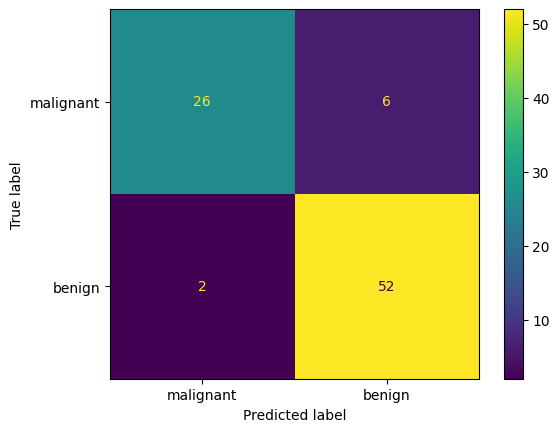

In [33]:
print("Confusion Matrix")
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["malignant","benign"])
disp.plot()
plt.show()

In [38]:

feature_imp = final_model.get_feature_importance()  # Call the method!
feature_names=dataset.feature_names # type: ignore

# sort by importance (aka highest I.G)
if feature_imp is not None:
    imp_indices=np.argsort(feature_imp)[::-1]
    print(f"10 Most important features:")
    for i ,idx in enumerate(imp_indices[:10],1):
        print(f"{i}: {feature_names[idx]} {feature_imp[idx]:.4f}")

10 Most important features:
1: mean texture 2.6259
2: worst concave points 1.6624
3: worst area 1.4112
4: mean smoothness 1.3122
5: worst perimeter 1.2760
6: worst texture 1.1521
7: compactness error 1.1492
8: worst radius 1.0230
9: mean radius 0.7219
10: area error 0.6414
